# Infant-mother interaction

This tutorial is based on an example extracted from the data analyzed in {cite:p}`DobaEtAl22` article see [DoPN22]_.

Behavioral interaction between mother and her infant are video recorded while playing. Behaviors are encoded according to several categories. They are recorded during a first session before the mother leave temporally the room and after the mother comes back. The software used to encode the videos is called codix see [PDPN24]_

## Read data

In [14]:
import sys
sys.path.append('../../../symbolic')

import sequence as S # sequence module from scikits.symbolic
import iosymb as IO # IO from scikits.symbolic
import viz as V

data_S1 = IO.read_codix('data/209_S1')
data_S2 = IO.read_codix('data/209_S2')

The `read_codix` function returns a dictionary organized as `data[person][code]` which value is a symbolic `Sequence` coded according to a specific `Alphabet`:

In [15]:
for person in data_S1.keys():
    print(person+': ')
    for code in data_S1[person].keys():
        print("\t"+code+': \t', data_S1[person][code].alphabet)

Bebe: 
	Mouvement: 	 Alphabet[State(0 | Non), State(1 | Oui)]
	Expession_faciale: 	 Alphabet[State(0 | neutre), State(1 | sourit), State(2 | negatif)]
	Regard: 	 Alphabet[State(0 | ailleurs), State(1 | vers_la_mere)]
	Sons: 	 Alphabet[State(0 | Silence), State(1 | vocalisation), State(2 | negatif)]
Mere: 
	Expression_faciale: 	 Alphabet[State(0 | Neutre), State(1 | Expressif)]
	Sti_motrices: 	 Alphabet[State(0 | Absence), State(1 | Avec_contact), State(2 | Sans_contact)]
	Regard: 	 Alphabet[State(0 | Ailleurs), State(1 | vers_bebe)]
	Sti_verbale: 	 Alphabet[State(0 | Silence), State(1 | Inference), State(2 | Sons)]
	Jeu: 	 Alphabet[State(0 | Absence), State(1 | Avec_objet), State(2 | Sans_objet)]


In the study we discarded the facial expression code since the face of the mother and the infant could not be seen all the time. 

In [16]:
bmv1 = data_S1['Bebe']['Mouvement']
bcv1 = data_S1['Bebe']['Sons']
bre1 = data_S1['Bebe']['Regard']
bmv2 = data_S2['Bebe']['Mouvement']
bcv2 = data_S2['Bebe']['Sons']
bre2 = data_S2['Bebe']['Regard']

mmv1 = data_S1['Mere']['Sti_motrices']
mcv1 = data_S1['Mere']['Sti_verbale']
mre1 = data_S1['Mere']['Regard']
mmv2 = data_S2['Mere']['Sti_motrices']
mcv2 = data_S2['Mere']['Sti_verbale']
mre2 = data_S2['Mere']['Regard']

# rename motor behavior in English :-)
eng_mvt = {0:'NoMvt', 1:'Touch', 2:'NoTouch'}
mmv1.alphabet.rename(eng_mvt)
mmv2.alphabet.rename(eng_mvt)

## Recode and transform sequences

The infant's behavior was also recoded according to a general level of activity.

First, the three sequences (motor, verbal and gaze) are recoded according to the cartesian product of the alphabets:

In [17]:
bbstate1 = S.recode([bmv1, bcv1, bre1], new_alphabet=True, names=['Mvt','Verb','Gaz'])
bbstate2 = S.recode([bmv2, bcv2, bre2], new_alphabet=True, names=['Mvt','Verb','Gaz'])
print(bbstate1.alphabet) # some pretty print would be better...

Alphabet[State(0 | Mvt_Non+Verb_Silence+Gaz_ailleurs), State(1 | Mvt_Non+Verb_Silence+Gaz_vers_la_mere), State(2 | Mvt_Non+Verb_vocalisation+Gaz_ailleurs), State(3 | Mvt_Non+Verb_vocalisation+Gaz_vers_la_mere), State(4 | Mvt_Non+Verb_negatif+Gaz_ailleurs), State(5 | Mvt_Non+Verb_negatif+Gaz_vers_la_mere), State(6 | Mvt_Oui+Verb_Silence+Gaz_ailleurs), State(7 | Mvt_Oui+Verb_Silence+Gaz_vers_la_mere), State(8 | Mvt_Oui+Verb_vocalisation+Gaz_ailleurs), State(9 | Mvt_Oui+Verb_vocalisation+Gaz_vers_la_mere), State(10 | Mvt_Oui+Verb_negatif+Gaz_ailleurs), State(11 | Mvt_Oui+Verb_negatif+Gaz_vers_la_mere)]


Then, states are transformed according to a correspondance table:

In [18]:
naint = S.Alphabet(['Low','Moderate', 'High'])
bbglo1 = S.transform(bbstate1, [0,0,0,1,0,1,0,1,1,2,1,2], new_alphabet=naint)
bbglo2 = S.transform(bbstate2, [0,0,0,1,0,1,0,1,1,2,1,2], new_alphabet=naint)
bbglo1

Sequence: [0 0 1 1 0 1 0 2 1 0 0 0 1 1 0 1 1 1 1 0 2 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1
 1 1 1 2 1 0 0 0 0 0 1 1 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 2 1 1 1 1 1 1 2 1
 1 1 1 1 0 0 1 1 1 1 2 1 2 1 1 1 0 0 1 1 2 0 0 0 2 1 2 2 2 2 2 2 2 0 0 1 0
 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 2 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1
 2 0 0 1 0 1 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 2 1 2 2 1 2
 2 1 1 1 0 0 1 1 2 2 2 1 1 1 2 2 1 0 0 0 0 2 2 2 1 1 0 0 0 0 0 1 1 2 0 0 0
 0 0 0 0 0 0 0 0 0 0 0]
Alphabet[State(0 | Low), State(1 | Moderate), State(2 | High)]
N = 233 ; k = 3

## Visualise sequences

### One sequence

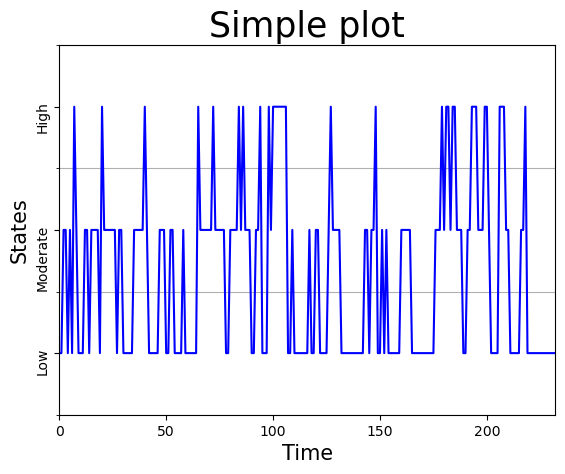

In [19]:
V.plot(bbglo1)

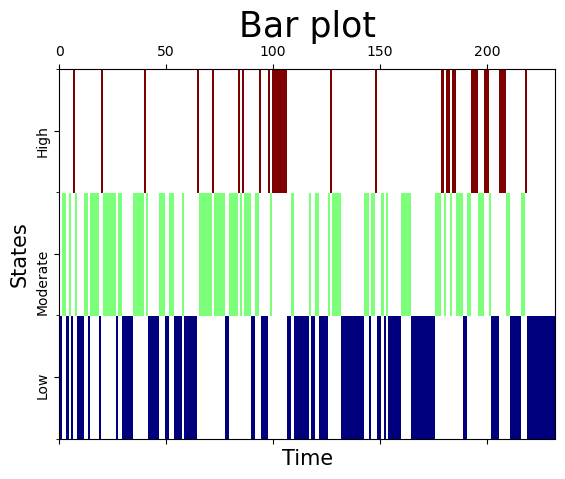

In [20]:
V.plot_bar(bbglo1)

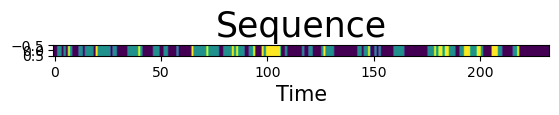

In [21]:
V.plot_color(bbglo1)

### Two sequences

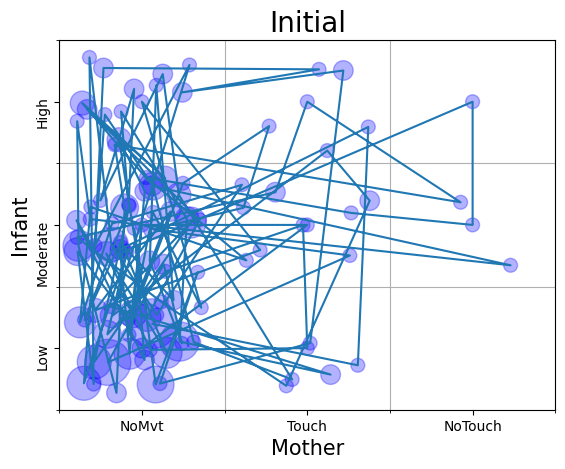

In [26]:
V.plot_grid(mmv1, bbglo1, xlabel='Mother', ylabel='Infant', title='Initial', titlesize=20)

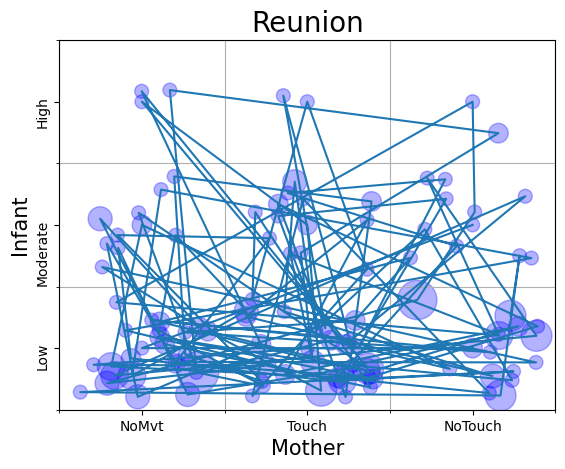

In [23]:
V.plot_grid(mmv2, bbglo2, xlabel='Mother', ylabel='Infant', title='Reunion', titlesize=20)

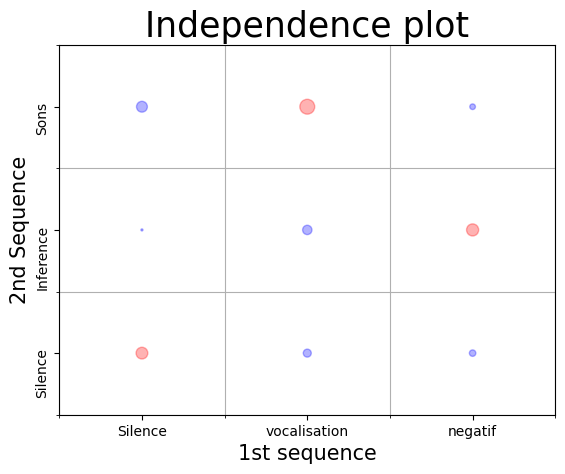

In [24]:
V.plot_independence(bcv1,mcv1, scale=2500)